In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    average_precision_score
)

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize
from collections import Counter
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
# from scikitplot.metrics import plot_roc 
# from scikitplot.metrics import plot_precision_recall

from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.metrics import PrecisionRecallDisplay

Loading the datasets: we substitute `runtimeMinutes` for `logRuntime`. We drop `originalTitle` bc it's useless.

In [3]:
# Train

df = pd.read_csv("../results/train_clean.csv", index_col=0)
df['countryOfOrigin'] = df['countryOfOrigin'].apply(ast.literal_eval)
df['genres'] = df['genres'].apply(ast.literal_eval)
df['logRuntime'] = np.log(df['runtimeMinutes'] + 1) 
df.drop(columns=['runtimeMinutes', 'originalTitle'], inplace=True)

In [4]:
# Test

df_test = pd.read_csv("../results/test_clean.csv", index_col=0)
df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval) 
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['logRuntime'] = np.log(df_test['runtimeMinutes'] + 1)
df_test.drop(columns=['runtimeMinutes', 'originalTitle'], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16431 entries, 0 to 16430
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rating                 16431 non-null  object 
 1   startYear              16431 non-null  int64  
 2   numVotes               16431 non-null  float64
 3   totalImages            16431 non-null  float64
 4   totalCredits           16431 non-null  float64
 5   titleType              16431 non-null  object 
 6   canHaveEpisodes        16431 non-null  bool   
 7   numRegions             16431 non-null  float64
 8   countryOfOrigin        16431 non-null  object 
 9   genres                 16431 non-null  object 
 10  ratingNum              16431 non-null  int64  
 11  numGenres              16431 non-null  int64  
 12  criticReviewsRatio     16431 non-null  float64
 13  awardsAndNominations   16431 non-null  bool   
 14  hasVideos              16431 non-null  bool   
 15  moreCou

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5478 entries, 0 to 5477
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rating                 5478 non-null   object 
 1   startYear              5478 non-null   int64  
 2   numVotes               5478 non-null   float64
 3   totalImages            5478 non-null   float64
 4   totalCredits           5478 non-null   float64
 5   titleType              5478 non-null   object 
 6   canHaveEpisodes        5478 non-null   bool   
 7   numRegions             5478 non-null   float64
 8   countryOfOrigin        5478 non-null   object 
 9   genres                 5478 non-null   object 
 10  ratingNum              5478 non-null   int64  
 11  numGenres              5478 non-null   int64  
 12  criticReviewsRatio     5478 non-null   float64
 13  awardsAndNominations   5478 non-null   bool   
 14  hasVideos              5478 non-null   bool   
 15  moreCount

# Target variable: titleType

In [7]:
y_train = df['titleType']#.values
y_test = df_test['titleType']#.values

## DT using only numeric features (comparable to KNN and GaussianNB)

In [8]:
# numeric attributes
attributes = df.select_dtypes(include=['int64', 'float64']).columns
attributes

Index(['startYear', 'numVotes', 'totalImages', 'totalCredits', 'numRegions',
       'ratingNum', 'numGenres', 'criticReviewsRatio', 'logRuntime'],
      dtype='object')

In [9]:
X_train = df[attributes].values
X_test = df_test[attributes].values


### Hyperparameter tuning

In [10]:
%%time

param_grid = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [2, 5, 10, 15, 20, 30, 50, 100],
    'min_samples_leaf': [1, 5, 10, 15, 20, 30, 50, 100],
    'criterion': ['gini', 'entropy']
}

clf = DecisionTreeClassifier(random_state=42)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_grid,
    cv=RepeatedStratifiedKFold(random_state=0, n_splits=5, n_repeats=5),
    n_jobs=-1,
    refit=True, #refitta il miglior modello
    n_iter= 500,
    #verbose=2
    random_state=42
)

CPU times: total: 0 ns
Wall time: 0 ns


In [11]:
random_search.fit(X_train, y_train)
clf = random_search.best_estimator_ 

In [12]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 50, 'min_samples_leaf': 10, 'max_depth': np.int64(10), 'criterion': 'gini'} 0.8208265283052198


### Post-Pruning
Might not be needed, since we did pre-pruning.

In [13]:
path = clf.cost_complexity_pruning_path(X_train, y_train) #calcoli il path sul train
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [14]:
# We fix the hyperparameters we found; we initalize different models for all different ccp_alphas

dts = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha, **random_search.best_params_)
    dt.fit(X_train, y_train)
    dts.append(dt)

In [15]:
train_scores = [dt.score(X_train, y_train) for dt in dts]
test_scores = [dt.score(X_test, y_test) for dt in dts]

train_macro_f1_scores = [f1_score(y_train, dt.predict(X_train), average='macro') for dt in dts]
test_macro_f1_scores = [f1_score(y_test, dt.predict(X_test), average='macro') for dt in dts]

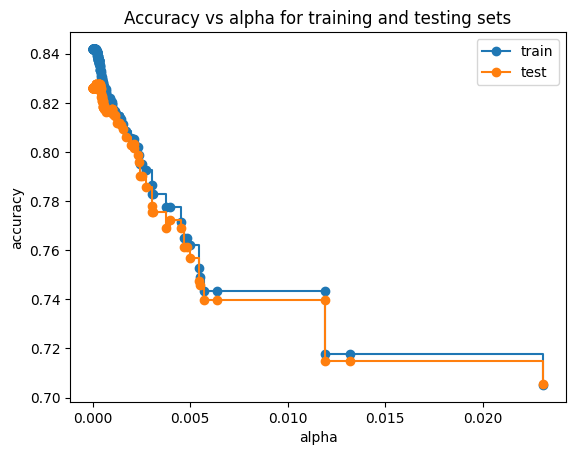

In [16]:
# Vediamo come cambia la performance di questi modelli diversi
# better visualization filtering out extreme alphas

ccp_alphas_filtered = [a for a in ccp_alphas if a < 0.1]
# Find indices of filtered alphas
filtered_indices = [i for i, a in enumerate(ccp_alphas) if a < 0.1]
train_scores_filtered = [train_scores[i] for i in filtered_indices]
test_scores_filtered = [test_scores[i] for i in filtered_indices]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas_filtered, train_scores_filtered, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas_filtered, test_scores_filtered, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

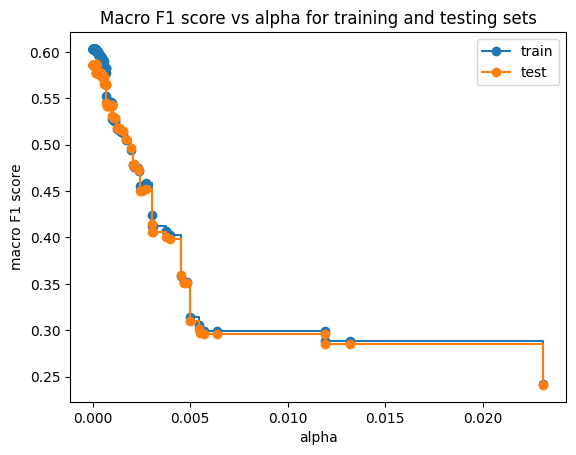

In [17]:
train_macro_f1_scores_filtered = [train_macro_f1_scores[i] for i in filtered_indices]
test_macro_f1_scores_filtered = [test_macro_f1_scores[i] for i in filtered_indices]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("macro F1 score")
ax.set_title("Macro F1 score vs alpha for training and testing sets")
ax.plot(ccp_alphas_filtered, train_macro_f1_scores_filtered, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas_filtered, test_macro_f1_scores_filtered, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [18]:
# best alpha (where test accuracy is max)
idx_best_alpha = np.argmax(test_scores)
best_alpha = ccp_alphas[idx_best_alpha]
print("------------ BEST ALPHA FOR TEST ACCURACY ------------")
print(f"Best alpha: {best_alpha}, Test accuracy: {test_scores[idx_best_alpha]}, Test macro F1: {test_macro_f1_scores[idx_best_alpha]}")


# best alpha (where test macro F1 is max)
idx_best_alpha_f1 = np.argmax(test_macro_f1_scores)
best_alpha_f1 = ccp_alphas[idx_best_alpha_f1]
print("\n------------ BEST ALPHA FOR TEST MACRO F1 ------------")
print(f"Best alpha: {best_alpha_f1}, Test accuracy: {test_scores[idx_best_alpha_f1]}, Test macro F1: {test_macro_f1_scores[idx_best_alpha_f1]}")

------------ BEST ALPHA FOR TEST ACCURACY ------------
Best alpha: 0.0003344916822918477, Test accuracy: 0.8278568820737495, Test macro F1: 0.5784560827401626

------------ BEST ALPHA FOR TEST MACRO F1 ------------
Best alpha: 0.0001711481332412803, Test accuracy: 0.8274917853231106, Test macro F1: 0.5873521690534813


In [19]:
tree_full = dts[0]  # unpruned (ccp_alpha=0.0)


print("Unpruned tree:")
print(f"  Depth: {tree_full.get_depth()}")
print(f"  Leaves: {tree_full.get_n_leaves()}")

tree_pruned = dts[idx_best_alpha]  # pruned with best alpha
print("\nPruned tree (BEST ALPHA FOR ACCURACY):")
print(f"  Depth: {tree_pruned.get_depth()}")
print(f"  Leaves: {tree_pruned.get_n_leaves()}")

tree_pruned = dts[idx_best_alpha_f1]  # pruned with best alpha
print("\nPruned tree (BEST ALPHA FOR MACRO F1):")
print(f"  Depth: {tree_pruned.get_depth()}")
print(f"  Leaves: {tree_pruned.get_n_leaves()}")

Unpruned tree:
  Depth: 10
  Leaves: 272

Pruned tree (BEST ALPHA FOR ACCURACY):
  Depth: 10
  Leaves: 101

Pruned tree (BEST ALPHA FOR MACRO F1):
  Depth: 10
  Leaves: 152


The train and test accuracy, as well as the train and test macro F1, against the different alphas are quite similar and have strictly decreasing trends.

The best alphas are very small; still they make the tree more compact: the depth is the same, but the number of leaves becomes smaller. The two values are similar, but we choose the alpha that optmizes the macro F1 score, since classes are not balanced (→ for all models).

### Model

In [20]:
clf = DecisionTreeClassifier(ccp_alpha=best_alpha_f1, **random_search.best_params_)
clf.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0001711481332412803),
                       max_depth=np.int64(10), min_samples_leaf=10,
                       min_samples_split=50)

In [21]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

Train and test accuracy: very similar, no overfitting.

In [22]:
#performance su train e test set
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.8410930558091413
Train F1-score [0.89660428 0.8852459  0.89656625 0.41309824 0.40400668 0.78380443
 0.         0.31876607 0.57738573 0.84249084]

Test Accuracy 0.8274917853231106
Test F1-score [0.8955     0.84950249 0.8794768  0.36486486 0.47727273 0.74794842
 0.         0.31067961 0.51578947 0.83248731]


Comparison to dummy classifier: accuracy 0.827 vs 0.233, macro F1: 0.587 vs 0.102.

Unsurprisingly, the 3 target classes with the highest support have better performances (over 0.80 for all metrics). 

On the most popular classes:
- `movie`: best performances.
- `short`: little confusion (misclassified only for 3 other classes, in 51 cases it's `tvEpisode`: probably due to runtime)
- `tvEpisode`: some significant misclassification as `movie` and `short`.

Other things to point out:
- `videoGame`: though it has a small support, it has very good performances.
- `tvShort` is almost always classified as `short` (for its runtime). Nothing is ever classifies as `tvShort`: too small of a support.
- `tvMovie`: most of the times (almost half) it is misclassified as `movie`.

In [23]:
print(classification_report(y_test, y_test_pred, digits=3))

              precision    recall  f1-score   support

       movie      0.844     0.954     0.895      1877
       short      0.811     0.892     0.850       766
   tvEpisode      0.876     0.883     0.879      1599
tvMiniSeries      0.403     0.333     0.365        81
     tvMovie      0.745     0.351     0.477       299
    tvSeries      0.786     0.714     0.748       447
     tvShort      0.000     0.000     0.000        16
   tvSpecial      0.296     0.327     0.311        49
       video      0.754     0.392     0.516       250
   videoGame      0.796     0.872     0.832        94

    accuracy                          0.827      5478
   macro avg      0.631     0.572     0.587      5478
weighted avg      0.820     0.827     0.815      5478



c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

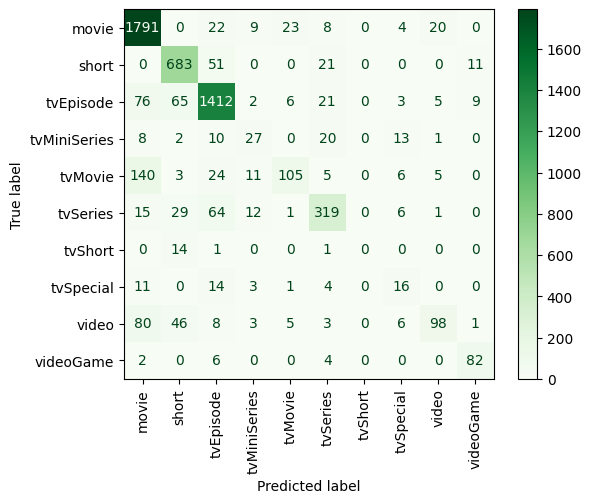

In [24]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_test_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

In [25]:
# Feature importance

zipped = zip(attributes, clf.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

logRuntime 0.7490241811326063
numRegions 0.10007870999940646
totalCredits 0.04735430413646348
startYear 0.03372530241682102
totalImages 0.0237517959712893
numGenres 0.01969522142078576
numVotes 0.014347591574357044
ratingNum 0.006998280991236493
criticReviewsRatio 0.0050246123570341205


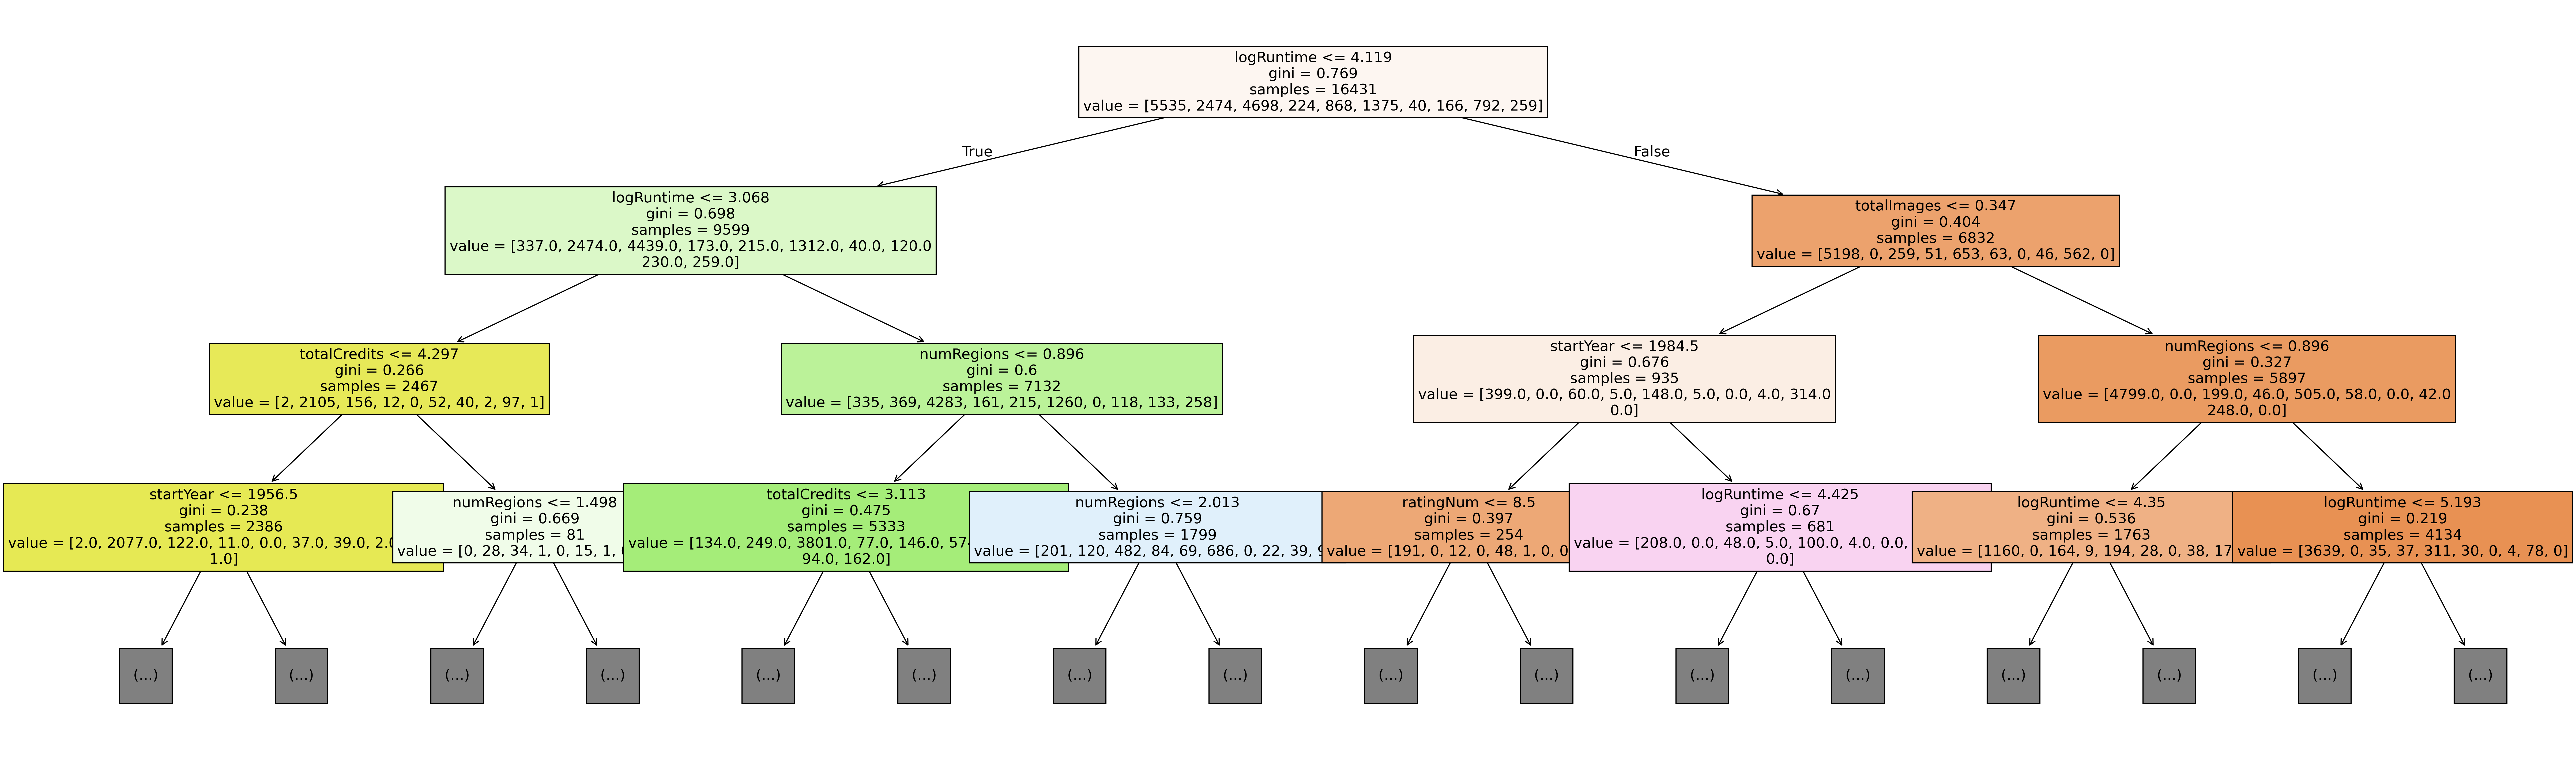

In [26]:
plt.figure(figsize=(40, 12), dpi=300)
plot_tree(clf, feature_names=attributes, filled=True, max_depth=3, fontsize=13)
plt.show()

As expected, the most important feature is `logRuntime`; in fact, already after the first split, the right subtree has no short, tvShort, and videoGame. After this, a larger number of images helps distinguishing these longer movies.

On the left subtree, after the second split for `logRuntime`, the tree is able to isolate medium-lenght `tvMovies` (and almost entirely medium-lenght `movies` and `videoGames`). After this, the split for `totalCredits` is important for isolating shorter shorts (which have fewer credits), whereas the split for `numRegions `is important in isolating medium lenght tvEpisodes.



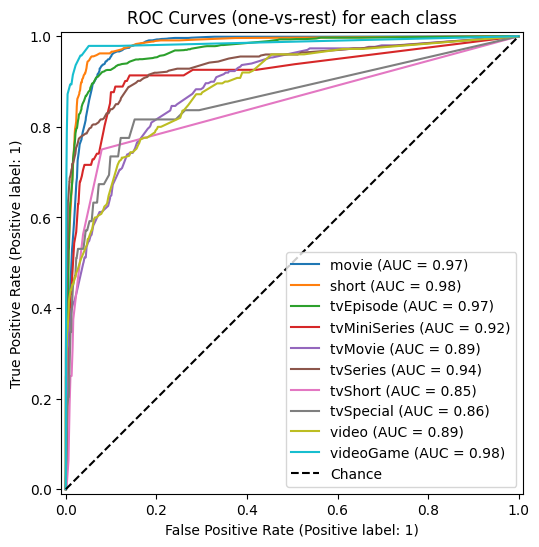

Macro-average ROC AUC: 0.925


In [27]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test) #predicted probabilities


plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")


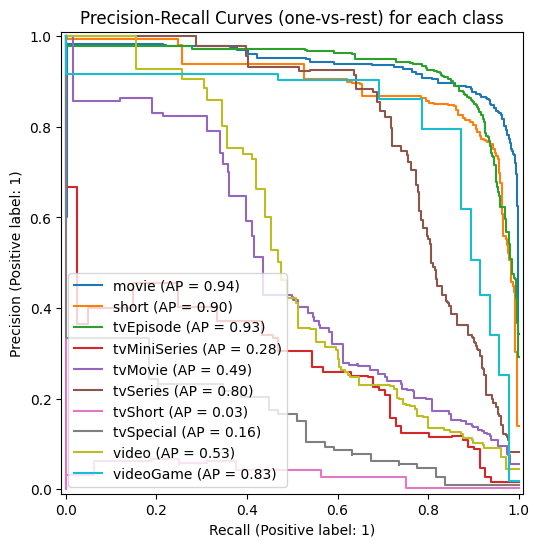

Macro average PR AUC: 0.589


In [28]:
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )

plt.legend()
plt.title("Precision-Recall Curves (one-vs-rest) for each class")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")


Consistently with the situation photographed by the classification report the four most popular classes + videogames have the best performances, while the others struggle, especially the ones with the lowest support.

## DT using all features (comparable to CategoricalNB)

### Pre-processing

- Categorical features
  - We don't use `originalTitle` and `rating` (bc we're using `ratingNum` → treated as a numeric var).
  - Multi-label variables: We binarize  `countryOfOrigin` and `genres`. Since `countryOfOrigin` has many unique values, we only keep the 40 most frequent to reduce dimensionality and noise from rare countries, collapsing all other countries to 'Other'.
  - Boolean: Keep as is.

In [29]:
mbl = MultiLabelBinarizer()

In [30]:
all_countries = [country for countries in df['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 40
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

def clean_countries(countries):
    return [c if c in top_countries else "Other" for c in countries]

df['country_cleaned'] = df['countryOfOrigin'].apply(clean_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_countries)

In [31]:
countries_df = pd.DataFrame(mbl.fit_transform(df['country_cleaned']), columns=mbl.classes_, index=df.index)
genres_df = pd.DataFrame(mbl.fit_transform(df['genres']), columns=mbl.classes_, index=df.index)

countries_df_test = pd.DataFrame(mbl.fit_transform(df_test['country_cleaned']), columns=mbl.classes_, index=df_test.index)
genres_df_test = pd.DataFrame(mbl.fit_transform(df_test['genres']), columns=mbl.classes_, index=df_test.index)

In [32]:
# into numpy arrays
array_countries = countries_df.values
array_countries_test = countries_df_test.values

array_genres = genres_df.values
array_genres_test = genres_df_test.values

In [33]:
numeric_bool_cols = df.dtypes[(df.dtypes == 'float64') | (df.dtypes == 'int64') | (df.dtypes == 'bool')].index

X_numeric_bool = df[numeric_bool_cols].values
X_numeric__bool_test = df_test[numeric_bool_cols].values

In [34]:
X_train = np.hstack([X_numeric_bool, array_countries, array_genres])
X_test = np.hstack([X_numeric__bool_test, array_countries_test, array_genres_test])

attributes = list(numeric_bool_cols) + list(countries_df.columns) + list(genres_df.columns)
print(attributes)

['startYear', 'numVotes', 'totalImages', 'totalCredits', 'canHaveEpisodes', 'numRegions', 'ratingNum', 'numGenres', 'criticReviewsRatio', 'awardsAndNominations', 'hasVideos', 'moreCountriesOfOrigin', 'logRuntime', 'AR', 'AT', 'AU', 'BE', 'BR', 'CA', 'CH', 'CN', 'CSHH', 'DE', 'DK', 'EG', 'ES', 'FI', 'FR', 'GB', 'GR', 'HK', 'HU', 'IL', 'IN', 'IR', 'IT', 'JP', 'KR', 'MX', 'NL', 'NO', 'Other', 'PH', 'PL', 'PT', 'RO', 'RU', 'SE', 'SUHH', 'TR', 'TW', 'US', 'XWG', 'XYU', 'Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western']


In [35]:
y_train = df['titleType'].values
y_test = df_test['titleType'].values

### Hyperparameter tuning

In [36]:
%%time

clf = DecisionTreeClassifier(random_state=42)

random_search.fit(X_train, y_train)
clf = random_search.best_estimator_ 

CPU times: total: 24min 10s
Wall time: 37min 8s


In [37]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 30, 'min_samples_leaf': 5, 'max_depth': np.int64(13), 'criterion': 'entropy'} 0.8831477513086189


### Post-Pruning

In [38]:
path = clf.cost_complexity_pruning_path(X_train, y_train) #calcoli il path sul train
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [39]:
# We fix the hyperparameters we found; we initalize different models for all different ccp_alphas

dts = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha, **random_search.best_params_)
    dt.fit(X_train, y_train)
    dts.append(dt)

In [40]:
train_scores = [dt.score(X_train, y_train) for dt in dts]
test_scores = [dt.score(X_test, y_test) for dt in dts]

train_macro_f1_scores = [f1_score(y_train, dt.predict(X_train), average='macro') for dt in dts]
test_macro_f1_scores = [f1_score(y_test, dt.predict(X_test), average='macro') for dt in dts]

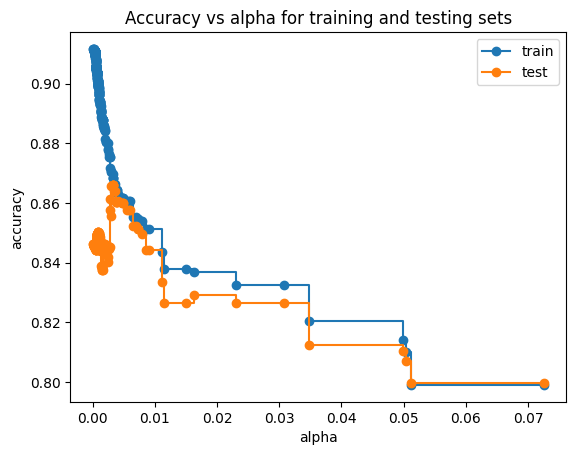

In [41]:
# Vediamo come cambia la performance di questi modelli diversi
# better visualization filtering out extreme alphas

ccp_alphas_filtered = [a for a in ccp_alphas if a < 0.1]
# Find indices of filtered alphas
filtered_indices = [i for i, a in enumerate(ccp_alphas) if a < 0.1]
train_scores_filtered = [train_scores[i] for i in filtered_indices]
test_scores_filtered = [test_scores[i] for i in filtered_indices]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas_filtered, train_scores_filtered, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas_filtered, test_scores_filtered, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

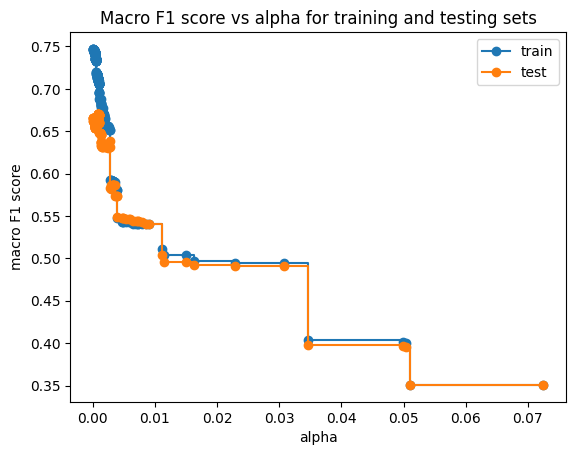

In [42]:
train_macro_f1_scores_filtered = [train_macro_f1_scores[i] for i in filtered_indices]
test_macro_f1_scores_filtered = [test_macro_f1_scores[i] for i in filtered_indices]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("macro F1 score")
ax.set_title("Macro F1 score vs alpha for training and testing sets")
ax.plot(ccp_alphas_filtered, train_macro_f1_scores_filtered, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas_filtered, test_macro_f1_scores_filtered, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [43]:
# best alpha (where test accuracy is max)
idx_best_alpha = np.argmax(test_scores)
best_alpha = ccp_alphas[idx_best_alpha]
print("------------ BEST ALPHA FOR TEST ACCURACY ------------")
print(f"Best alpha: {best_alpha}, Test accuracy: {test_scores[idx_best_alpha]}, Test macro F1: {test_macro_f1_scores[idx_best_alpha]}")


# best alpha (where test macro F1 is max)
idx_best_alpha_f1 = np.argmax(test_macro_f1_scores)
best_alpha_f1 = ccp_alphas[idx_best_alpha_f1]
print("\n------------ BEST ALPHA FOR TEST MACRO F1 ------------")
print(f"Best alpha: {best_alpha_f1}, Test accuracy: {test_scores[idx_best_alpha_f1]}, Test macro F1: {test_macro_f1_scores[idx_best_alpha_f1]}")

------------ BEST ALPHA FOR TEST ACCURACY ------------
Best alpha: 0.0032171201138950292, Test accuracy: 0.8660094925155166, Test macro F1: 0.5869931747889423

------------ BEST ALPHA FOR TEST MACRO F1 ------------
Best alpha: 0.0009008871615497852, Test accuracy: 0.8503103322380431, Test macro F1: 0.6702509336075165


In [44]:
tree_full = dts[0]  # unpruned (ccp_alpha=0.0)


print("Unpruned tree:")
print(f"  Depth: {tree_full.get_depth()}")
print(f"  Leaves: {tree_full.get_n_leaves()}")

tree_pruned = dts[idx_best_alpha]  # pruned with best alpha
print("\nPruned tree (BEST ALPHA FOR ACCURACY):")
print(f"  Depth: {tree_pruned.get_depth()}")
print(f"  Leaves: {tree_pruned.get_n_leaves()}")

tree_pruned = dts[idx_best_alpha_f1]  # pruned with best alpha
print("\nPruned tree (BEST ALPHA FOR MACRO F1):")
print(f"  Depth: {tree_pruned.get_depth()}")
print(f"  Leaves: {tree_pruned.get_n_leaves()}")

Unpruned tree:
  Depth: 13
  Leaves: 382

Pruned tree (BEST ALPHA FOR ACCURACY):
  Depth: 9
  Leaves: 41

Pruned tree (BEST ALPHA FOR MACRO F1):
  Depth: 13
  Leaves: 133


In this case, the tree w/ the best alpha for accuracy would be significantly more compact, but the loss in macro F1 is also greater. Again, we choose the best alpha for macro F1.

### Model

In [45]:
clf = DecisionTreeClassifier(ccp_alpha=best_alpha_f1, **random_search.best_params_)
clf.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0009008871615497852),
                       criterion='entropy', max_depth=np.int64(13),
                       min_samples_leaf=5, min_samples_split=30)

In [46]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

As it is to be expected, the performance on the test set is slightly worse than on the training set, but they are nevertheless quite similar: pre-pruning (and post-pruning, to a smaller extent) have avoided overfitting.

In [47]:
#performance su train e test set
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.8992148986671535
Train F1-score [0.91725032 0.94690095 0.94543922 0.66363636 0.51436993 0.94633793
 0.         0.51879699 0.65974441 0.97455969]

Test Accuracy 0.8503103322380431
Test F1-score [0.89508363 0.85568761 0.87137203 0.63157895 0.50806452 0.9380531
 0.         0.47368421 0.59640103 0.93258427]


Comparison to dummy classifier: accuracy 0.850 vs 0.233, macro F1: 0.670 vs 0.102.

Wrt to the DT using only numerical features, there's much less overall confusion: classes are misclassified only as few other classes. The 'purest' (and best-performing class) is `short`, which is confused only 10 times for `tvEpisode`. The classes w/ more confusion are `tvEpisode` and `video`, probably due to their variable runtime.
 
Other things to point out:
- `tvSeries` and `tvMiniSeries`: now they are confused only amongst themselves. The information about serial format must have been important.

In [48]:
print(classification_report(y_test, y_test_pred, digits=3))

              precision    recall  f1-score   support

       movie      0.854     0.941     0.895      1877
       short      0.755     0.987     0.856       766
   tvEpisode      0.922     0.826     0.871      1599
tvMiniSeries      0.676     0.593     0.632        81
     tvMovie      0.640     0.421     0.508       299
    tvSeries      0.928     0.949     0.938       447
     tvShort      0.000     0.000     0.000        16
   tvSpecial      0.667     0.367     0.474        49
       video      0.835     0.464     0.596       250
   videoGame      0.988     0.883     0.933        94

    accuracy                          0.850      5478
   macro avg      0.726     0.643     0.670      5478
weighted avg      0.849     0.850     0.842      5478



c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camim\anaconda3\envs\dm1_project\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

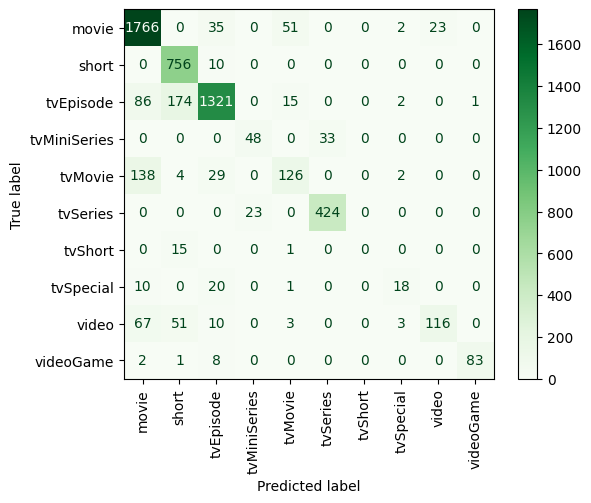

In [49]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_test_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Our intuitions are confirmed by the feature importance: the most important features are `logRuntime`, `canHaveEpisodes`, and `Short` (genre). Many countries and genres were not used in the decision.

In [50]:
# Feature importance

zipped = zip(attributes, clf.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

logRuntime 0.4654537083600508
canHaveEpisodes 0.1869039455293404
Short 0.182677188223828
startYear 0.028124859762604575
Adult 0.025966746786469826
numRegions 0.024385954448948928
totalCredits 0.017388438880865775
numGenres 0.012410533783010637
Documentary 0.007552082967632463
awardsAndNominations 0.006479218817066927
US 0.0050831266309576285
Drama 0.004881805234208469
numVotes 0.004280378721361975
IN 0.003604938764561636
GB 0.002531246312398151
ratingNum 0.0023596271232642274
Mystery 0.0021793554516209342
Music 0.0021568820682789113
hasVideos 0.0020829875556149856
DE 0.001662169053745161
KR 0.0015900267727345222
Comedy 0.0014061678672892925
Animation 0.001220308496680306
criticReviewsRatio 0.0011593230019879435
Action 0.0010535643829724562
XWG 0.0008859035382758016
Adventure 0.000850665600745437
FR 0.0008102176026508657
JP 0.0007481447467348417
Game-Show 0.0006381066205909713
Crime 0.0005006297992343366
CA 0.0005005275328415153
Family 0.0004712195614312555
totalImages 0.0
moreCountries

The right subtree leads to decently pure nodes quite fast: the first split on logRuntime removes `shorts`, `tvShorts` and `videoGames`. In two more splits we get a leaf with majority vote `video`: it must contain older adult videos.
More over we get to a node that only contains dramatic `tvMiniSeries` and `tvSeries`: they're not too long, are not adult content, they are serialized.

On the left side we also reach a leaf in 3 splits, which contains short `tvSeries`, and a quite pure node containing Series and MiniSeries which are not Short (as in genre).

In [ ]:
plt.figure(figsize=(20, 8), dpi=300)
plot_tree(clf, feature_names=attributes, filled=True, max_depth=3, fontsize=13)
plt.show()

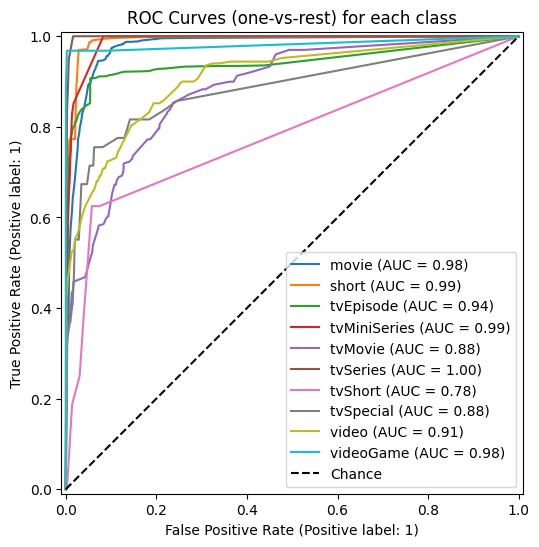

Macro-average ROC AUC: 0.933


In [52]:
#classes = np.unique(y_test)
#y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test) #predicted probabilities


plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")


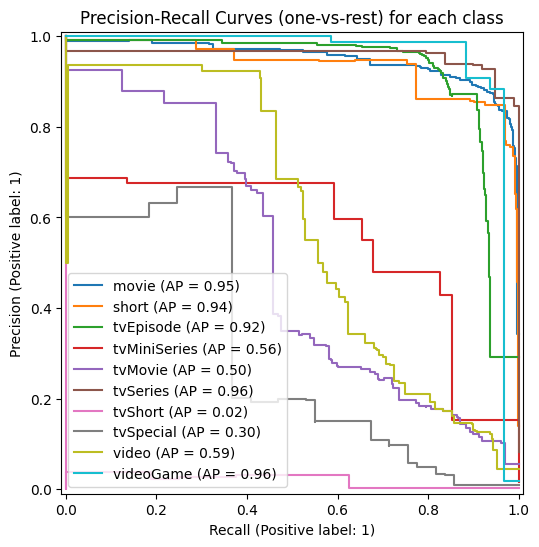

Macro average PR AUC: 0.669


In [53]:
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(classes):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )

plt.legend()
plt.title("Precision-Recall Curves (one-vs-rest) for each class")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")


The overall PR AUC improves. The score improves for every class (except tvShort); most signficantly for tvMiniSeries and tvSpecial (though the latter remains quite poor). There's also a remarkavle gain for videoGame and tvSeries: using all features now allows the model to distinguish them very well.

# Target variable: binned rating (low – medium-low – medium-high – high)

In [54]:
df['ratingCat'] = pd.qcut(df['ratingNum'], 4, labels=(1, 2, 3, 4))
df_test['ratingCat'] = pd.qcut(df_test['ratingNum'], 4, labels=(1, 2, 3, 4))

y_train = df['ratingCat']
y_test = df_test['ratingCat']

In [55]:
class_labels = ['Low', 'Medium-Low', 'Medium-High', 'High']

## DT using only numeric features (comparable to KNN and GaussianNB)

In [56]:
# numeric attributes
attributes = df.select_dtypes(include=['int64', 'float64']).columns
attributes = attributes.drop('ratingNum')
attributes

Index(['startYear', 'numVotes', 'totalImages', 'totalCredits', 'numRegions',
       'numGenres', 'criticReviewsRatio', 'logRuntime'],
      dtype='object')

In [57]:
X_train = df[attributes].values
X_test = df_test[attributes].values

### Hyperparameter tuning

In [58]:
%%time

clf = DecisionTreeClassifier(random_state=42)

random_search.fit(X_train, y_train)
clf = random_search.best_estimator_ 

CPU times: total: 31.5 s
Wall time: 4min 22s


In [59]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 2, 'min_samples_leaf': 50, 'max_depth': np.int64(6), 'criterion': 'gini'} 0.42064384660721954


### Post-Pruning

In [60]:
path = clf.cost_complexity_pruning_path(X_train, y_train) #calcoli il path sul train
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [61]:
# We fix the hyperparameters we found; we initalize different models for all different ccp_alphas

dts = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha, **random_search.best_params_)
    dt.fit(X_train, y_train)
    dts.append(dt)

print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        dts[-1].tree_.node_count, ccp_alphas[-1]
))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.022197461851569678


In [62]:
train_scores = [dt.score(X_train, y_train) for dt in dts]
test_scores = [dt.score(X_test, y_test) for dt in dts]

train_macro_f1_scores = [f1_score(y_train, dt.predict(X_train), average='macro') for dt in dts]
test_macro_f1_scores = [f1_score(y_test, dt.predict(X_test), average='macro') for dt in dts]

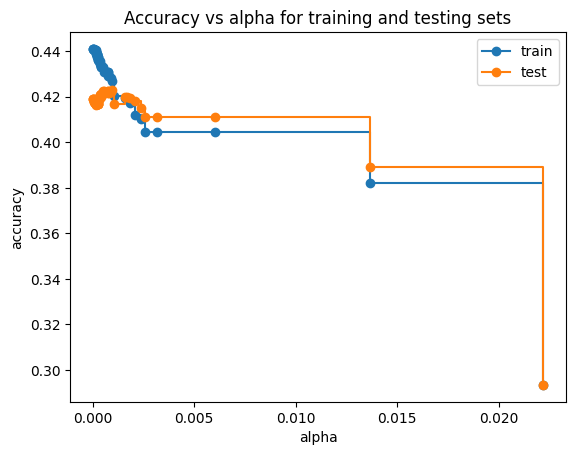

In [63]:
# Vediamo come cambia la performance di questi modelli diversi
# better visualization filtering out extreme alphas

ccp_alphas_filtered = [a for a in ccp_alphas if a < 0.1]
# Find indices of filtered alphas
filtered_indices = [i for i, a in enumerate(ccp_alphas) if a < 0.1]
train_scores_filtered = [train_scores[i] for i in filtered_indices]
test_scores_filtered = [test_scores[i] for i in filtered_indices]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas_filtered, train_scores_filtered, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas_filtered, test_scores_filtered, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

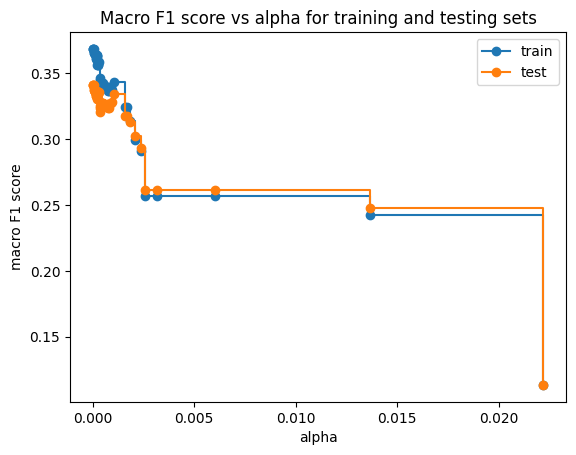

In [64]:
train_macro_f1_scores_filtered = [train_macro_f1_scores[i] for i in filtered_indices]
test_macro_f1_scores_filtered = [test_macro_f1_scores[i] for i in filtered_indices]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("macro F1 score")
ax.set_title("Macro F1 score vs alpha for training and testing sets")
ax.plot(ccp_alphas_filtered, train_macro_f1_scores_filtered, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas_filtered, test_macro_f1_scores_filtered, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [65]:
# best alpha (where test accuracy is max)
idx_best_alpha = np.argmax(test_scores)
best_alpha = ccp_alphas[idx_best_alpha]
print("------------ BEST ALPHA FOR TEST ACCURACY ------------")
print(f"Best alpha: {best_alpha}, Test accuracy: {test_scores[idx_best_alpha]}, Test macro F1: {test_macro_f1_scores[idx_best_alpha]}")


# best alpha (where test macro F1 is max)
idx_best_alpha_f1 = np.argmax(test_macro_f1_scores)
best_alpha_f1 = ccp_alphas[idx_best_alpha_f1]
print("\n------------ BEST ALPHA FOR TEST MACRO F1 ------------")
print(f"Best alpha: {best_alpha_f1}, Test accuracy: {test_scores[idx_best_alpha_f1]}, Test macro F1: {test_macro_f1_scores[idx_best_alpha_f1]}")

------------ BEST ALPHA FOR TEST ACCURACY ------------
Best alpha: 0.0009742711476919269, Test accuracy: 0.422964585615188, Test macro F1: 0.32790783572663085

------------ BEST ALPHA FOR TEST MACRO F1 ------------
Best alpha: 0.0, Test accuracy: 0.4189485213581599, Test macro F1: 0.34140808605906287


In [66]:
tree_full = dts[0]  # unpruned (ccp_alpha=0.0)


print("Unpruned tree:")
print(f"  Depth: {tree_full.get_depth()}")
print(f"  Leaves: {tree_full.get_n_leaves()}")

tree_pruned = dts[idx_best_alpha]  # pruned with best alpha
print("\nPruned tree (BEST ALPHA FOR ACCURACY):")
print(f"  Depth: {tree_pruned.get_depth()}")
print(f"  Leaves: {tree_pruned.get_n_leaves()}")

tree_pruned = dts[idx_best_alpha_f1]  # pruned with best alpha
print("\nPruned tree (BEST ALPHA FOR MACRO F1):")
print(f"  Depth: {tree_pruned.get_depth()}")
print(f"  Leaves: {tree_pruned.get_n_leaves()}")

Unpruned tree:
  Depth: 6
  Leaves: 55

Pruned tree (BEST ALPHA FOR ACCURACY):
  Depth: 6
  Leaves: 14

Pruned tree (BEST ALPHA FOR MACRO F1):
  Depth: 6
  Leaves: 55


### Model

In [67]:
clf = DecisionTreeClassifier(ccp_alpha=best_alpha_f1, **random_search.best_params_)
clf.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0), max_depth=np.int64(6),
                       min_samples_leaf=50)

In [68]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

Train and test accuracies are similar: no overfitting.

In [69]:
#performance su train e test set
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.4409956788996409
Train F1-score [0.55375659 0.26436285 0.51207729 0.14398354]

Test Accuracy 0.4189485213581599
Test F1-score [0.54847495 0.22810765 0.49129008 0.09775967]


Comparison to dummy classifier: accuracy 0.419 vs 0.264, macro F1 0.341 vs 0.248.

The most notable thing is the increadibly low recall for class `High`, even lower than the dummy classifier's: this class only had 2417 records in the training set, while all other had over 4500  – the model hasn't generalized on it, it barely classifies records as `High`.

`Medium-Low` has a lower recall and macro F1 than our benchmark; it is mostly classified as `Low` and `Medium-High`.

`Low` is the class w/ the best performances, and still it was correctly classified only around 65% of the times (recall). It is followed with similar, though slightly worse, performances by `Medium-High`. `Medium-High`is also correctly classified around 61% of the time (recall), but it's the most popular class, also for prediction: the model assigns this class around 43% of the times. 

In [70]:
print(classification_report(y_test, y_test_pred, digits=3, target_names= class_labels))

              precision    recall  f1-score   support

         Low      0.473     0.653     0.548      1542
  Medium-Low      0.326     0.175     0.228      1522
 Medium-High      0.414     0.605     0.491      1608
        High      0.273     0.060     0.098       806

    accuracy                          0.419      5478
   macro avg      0.371     0.373     0.341      5478
weighted avg      0.385     0.419     0.376      5478



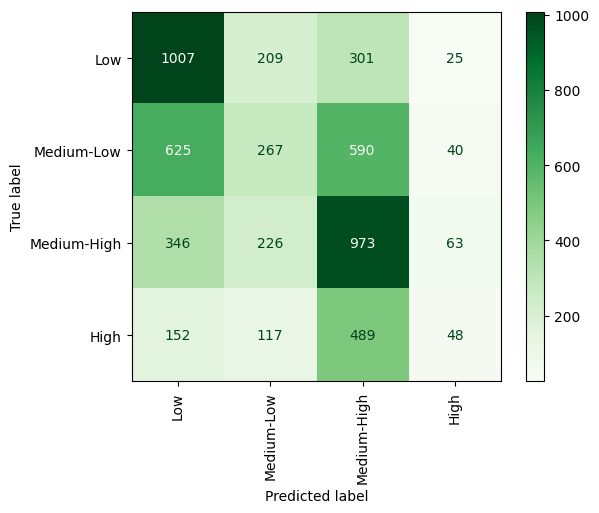

In [71]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_test_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens', display_labels= class_labels)
plt.show()

Perhaps surprisingly, the two most important features (`logRuntime` and `startYear`) don't seem all that related to the target variable, but they have proven important in clustering.


In [72]:
# Feature importance

zipped = zip(attributes, clf.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

logRuntime 0.4066565679129486
startYear 0.2903403023766305
numVotes 0.14209307362707768
numRegions 0.07724223668751702
totalCredits 0.043318611265174195
criticReviewsRatio 0.021951221054403763
totalImages 0.01494097912347265
numGenres 0.0034570079527754954


At the fourth level in the left subtree we can see that `Low` is starting to get isolated in a node containing shorter and older titles. Other than that, there's much confusion.

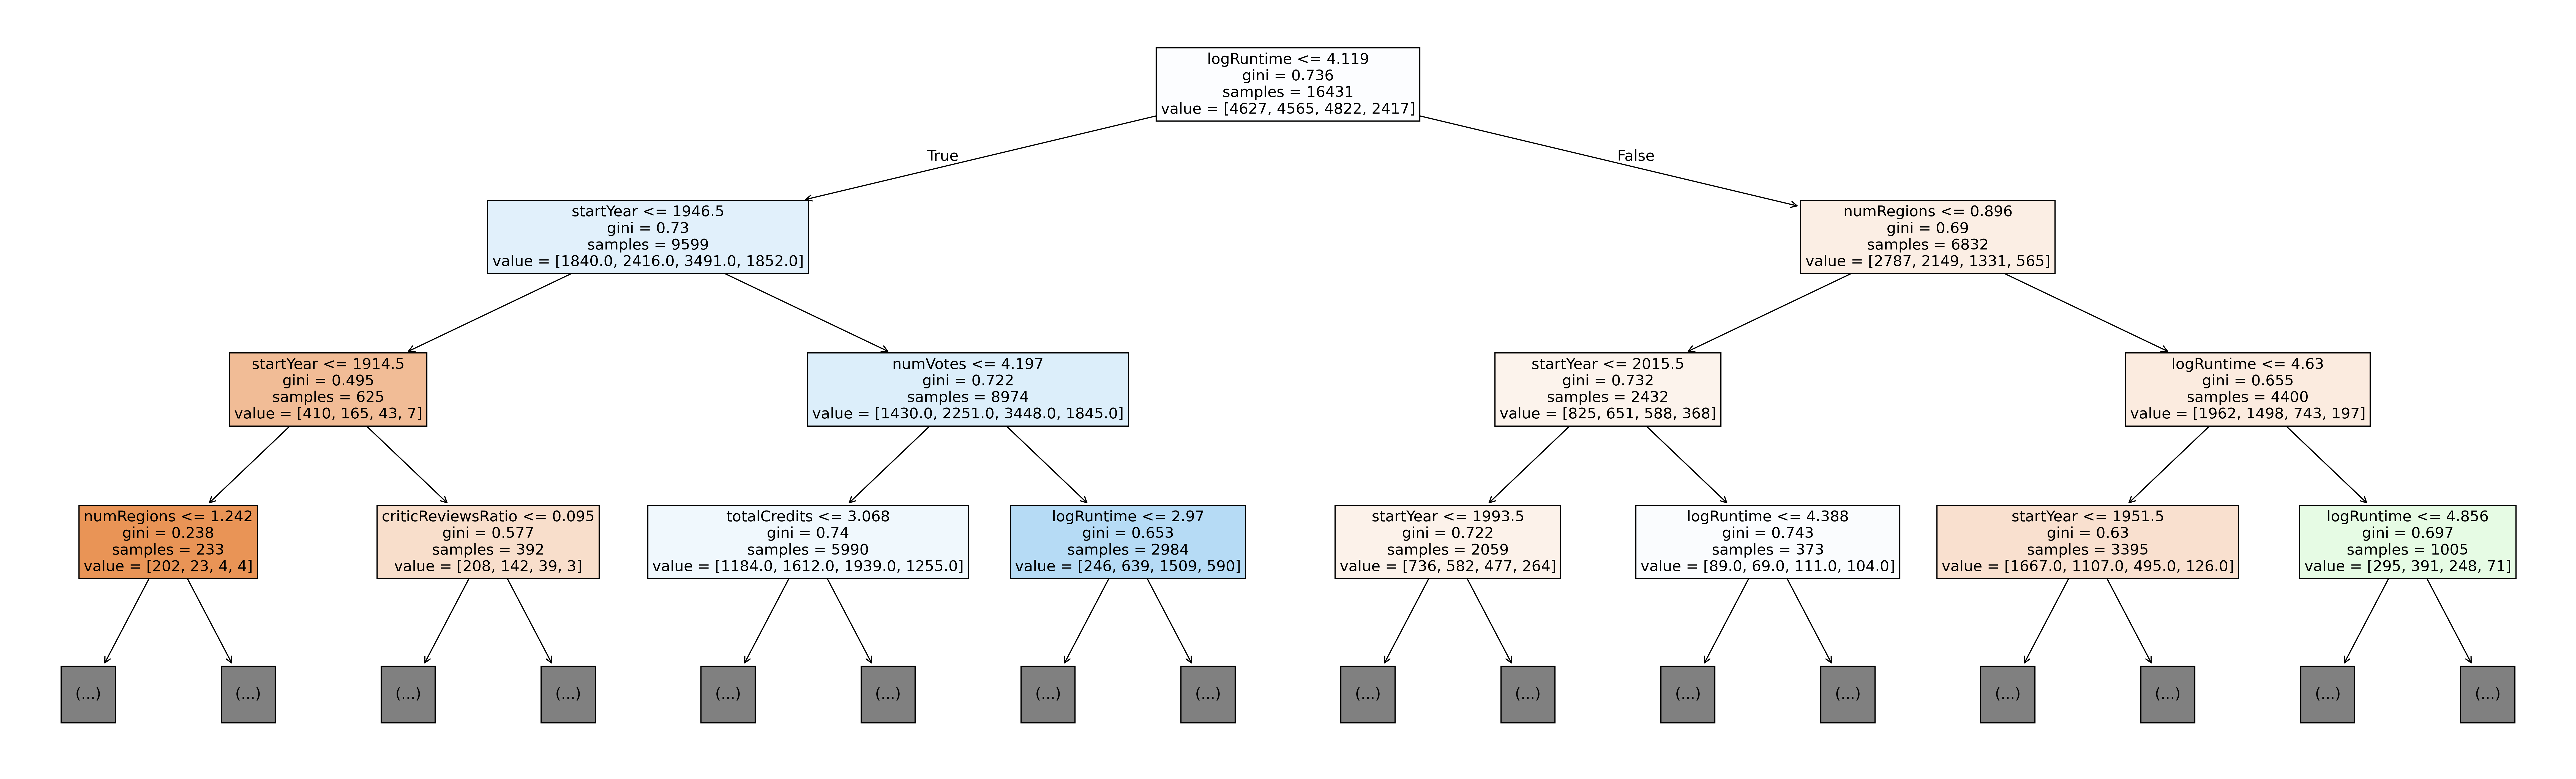

In [73]:
plt.figure(figsize=(40, 12), dpi=300)
plot_tree(clf, feature_names=attributes, filled=True, max_depth=3, fontsize=13)
plt.show()

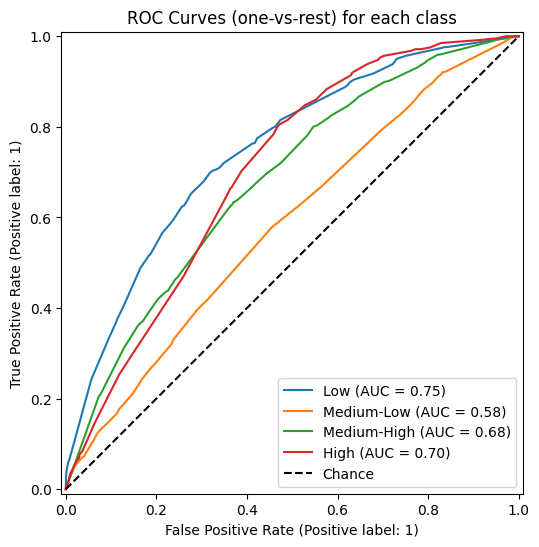

Macro-average ROC AUC: 0.678


In [74]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test) #predicted probabilities


plt.figure(figsize=(8, 6))
for i, class_label in zip(range(len(classes)), class_labels):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")


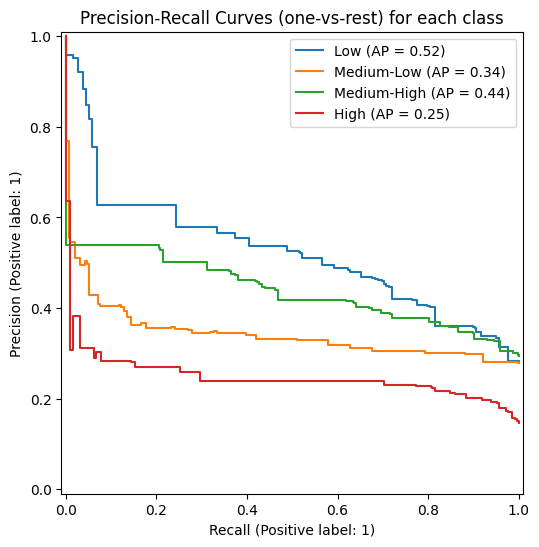

Macro average PR AUC: 0.388


In [75]:
plt.figure(figsize=(8, 6))
for i, class_label in zip(range(len(classes)), class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("Precision-Recall Curves (one-vs-rest) for each class")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")


All classes show an initial steep decline. The curves reiterate the situation photographed in the classification report.

## DT using all features

### Pre-Processing

In [76]:
bool_cols = df.dtypes[(df.dtypes == 'bool')].index

array_bool = df[bool_cols].values
array_bool_test = df_test[bool_cols].values

In [77]:
titleType_df = pd.get_dummies(df['titleType'])

array_titleType = pd.get_dummies(df['titleType']).values
array_titleType_test = pd.get_dummies(df_test['titleType']).values

In [78]:
X_train = np.hstack([X_train, array_bool, array_titleType, array_countries, array_genres])
X_test = np.hstack([X_test, array_bool_test, array_titleType_test, array_countries_test, array_genres_test])

attributes = list(attributes) + list(bool_cols) + list(titleType_df.columns) + list(countries_df.columns) + list(genres_df.columns)
print(attributes)

['startYear', 'numVotes', 'totalImages', 'totalCredits', 'numRegions', 'numGenres', 'criticReviewsRatio', 'logRuntime', 'canHaveEpisodes', 'awardsAndNominations', 'hasVideos', 'moreCountriesOfOrigin', 'movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 'tvSeries', 'tvShort', 'tvSpecial', 'video', 'videoGame', 'AR', 'AT', 'AU', 'BE', 'BR', 'CA', 'CH', 'CN', 'CSHH', 'DE', 'DK', 'EG', 'ES', 'FI', 'FR', 'GB', 'GR', 'HK', 'HU', 'IL', 'IN', 'IR', 'IT', 'JP', 'KR', 'MX', 'NL', 'NO', 'Other', 'PH', 'PL', 'PT', 'RO', 'RU', 'SE', 'SUHH', 'TR', 'TW', 'US', 'XWG', 'XYU', 'Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western']


### Hyperparameter Tuning

In [79]:
%%time

clf = DecisionTreeClassifier(random_state=42)

random_search.fit(X_train, y_train)
clf = random_search.best_estimator_ 

CPU times: total: 1min 3s
Wall time: 15min 9s


In [80]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 100, 'min_samples_leaf': 5, 'max_depth': np.int64(11), 'criterion': 'entropy'} 0.44419707210814624


### Post-Pruning

In [81]:
path = clf.cost_complexity_pruning_path(X_train, y_train) #calcoli il path sul train
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
# We fix the hyperparameters we found; we initalize different models for all different ccp_alphas

dts = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha, **random_search.best_params_)
    dt.fit(X_train, y_train)
    dts.append(dt)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.09044431821922827


In [83]:
train_scores = [dt.score(X_train, y_train) for dt in dts]
test_scores = [dt.score(X_test, y_test) for dt in dts]

train_macro_f1_scores = [f1_score(y_train, dt.predict(X_train), average='macro') for dt in dts]
test_macro_f1_scores = [f1_score(y_test, dt.predict(X_test), average='macro') for dt in dts]

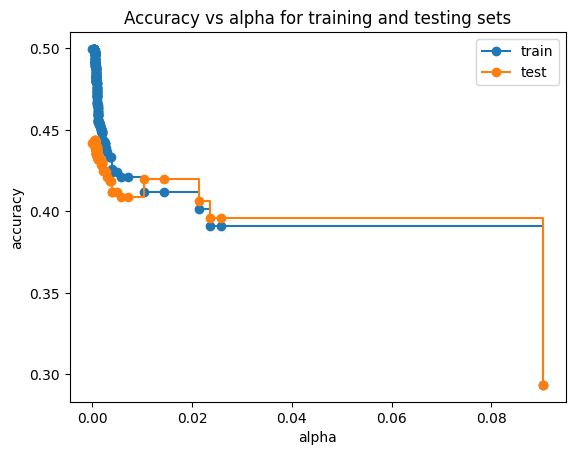

In [84]:
# Vediamo come cambia la performance di questi modelli diversi
# better visualization filtering out extreme alphas

ccp_alphas_filtered = [a for a in ccp_alphas if a < 0.1]
# Find indices of filtered alphas
filtered_indices = [i for i, a in enumerate(ccp_alphas) if a < 0.1]
train_scores_filtered = [train_scores[i] for i in filtered_indices]
test_scores_filtered = [test_scores[i] for i in filtered_indices]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas_filtered, train_scores_filtered, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas_filtered, test_scores_filtered, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

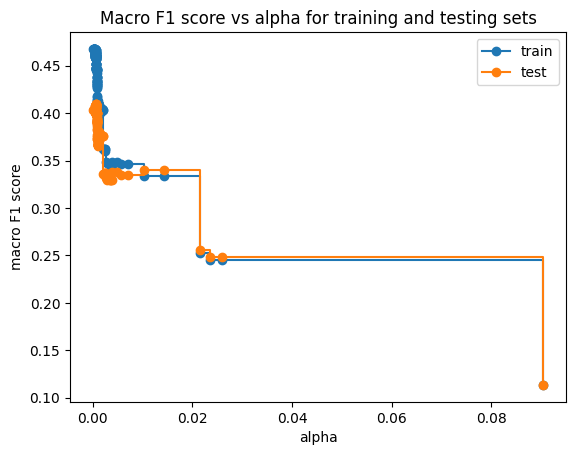

In [85]:
train_macro_f1_scores_filtered = [train_macro_f1_scores[i] for i in filtered_indices]
test_macro_f1_scores_filtered = [test_macro_f1_scores[i] for i in filtered_indices]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("macro F1 score")
ax.set_title("Macro F1 score vs alpha for training and testing sets")
ax.plot(ccp_alphas_filtered, train_macro_f1_scores_filtered, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas_filtered, test_macro_f1_scores_filtered, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [86]:
# best alpha (where test accuracy is max)
idx_best_alpha = np.argmax(test_scores)
best_alpha = ccp_alphas[idx_best_alpha]
print("------------ BEST ALPHA FOR TEST ACCURACY ------------")
print(f"Best alpha: {best_alpha}, Test accuracy: {test_scores[idx_best_alpha]}, Test macro F1: {test_macro_f1_scores[idx_best_alpha]}")


# best alpha (where test macro F1 is max)
idx_best_alpha_f1 = np.argmax(test_macro_f1_scores)
best_alpha_f1 = ccp_alphas[idx_best_alpha_f1]
print("\n------------ BEST ALPHA FOR TEST MACRO F1 ------------")
print(f"Best alpha: {best_alpha_f1}, Test accuracy: {test_scores[idx_best_alpha_f1]}, Test macro F1: {test_macro_f1_scores[idx_best_alpha_f1]}")

------------ BEST ALPHA FOR TEST ACCURACY ------------
Best alpha: 0.0005686608853152936, Test accuracy: 0.44377510040160645, Test macro F1: 0.40739451037049057

------------ BEST ALPHA FOR TEST MACRO F1 ------------
Best alpha: 0.0006274767822471855, Test accuracy: 0.438846294267981, Test macro F1: 0.4097612746942847


In [87]:
tree_full = dts[0]  # unpruned (ccp_alpha=0.0)


print("Unpruned tree:")
print(f"  Depth: {tree_full.get_depth()}")
print(f"  Leaves: {tree_full.get_n_leaves()}")

tree_pruned = dts[idx_best_alpha]  # pruned with best alpha
print("\nPruned tree (BEST ALPHA FOR ACCURACY):")
print(f"  Depth: {tree_pruned.get_depth()}")
print(f"  Leaves: {tree_pruned.get_n_leaves()}")

tree_pruned = dts[idx_best_alpha_f1]  # pruned with best alpha
print("\nPruned tree (BEST ALPHA FOR MACRO F1):")
print(f"  Depth: {tree_pruned.get_depth()}")
print(f"  Leaves: {tree_pruned.get_n_leaves()}")

Unpruned tree:
  Depth: 11
  Leaves: 223

Pruned tree (BEST ALPHA FOR ACCURACY):
  Depth: 11
  Leaves: 181

Pruned tree (BEST ALPHA FOR MACRO F1):
  Depth: 11
  Leaves: 156


### Model

In [88]:
clf = DecisionTreeClassifier(ccp_alpha=best_alpha_f1, **random_search.best_params_)
clf.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0006274767822471855),
                       criterion='entropy', max_depth=np.int64(11),
                       min_samples_leaf=5, min_samples_split=100)

In [89]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

The gap between train and test is slightly bigger than before, but not alarmingly.

In [90]:
#performance su train e test set
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.48877122512324267
Train F1-score [0.58576454 0.4099768  0.52266563 0.34571966]

Test Accuracy 0.438846294267981
Test F1-score [0.54065407 0.33546553 0.49327878 0.26964672]


Comparison to dummy classifier: accuracy 0.439 vs 0.264, macro F1 0.410 vs 0.248. There's an overall gain in performance using all features.

The most dramatic improvement has been for the lowest performing class, High, especially for its recall, which finally surpasses the benchmark. Medium-Low has also seen a great improvement in recall. Nevertheless, they still get misclassified most of the time.

Low has suffered a small decrease in recall (and macro F1) in turn, but remains the best performing class.




In [91]:
print(classification_report(y_test, y_test_pred, digits=3, target_names= class_labels))

              precision    recall  f1-score   support

         Low      0.503     0.584     0.541      1542
  Medium-Low      0.365     0.310     0.335      1522
 Medium-High      0.465     0.525     0.493      1608
        High      0.322     0.232     0.270       806

    accuracy                          0.439      5478
   macro avg      0.414     0.413     0.410      5478
weighted avg      0.427     0.439     0.430      5478



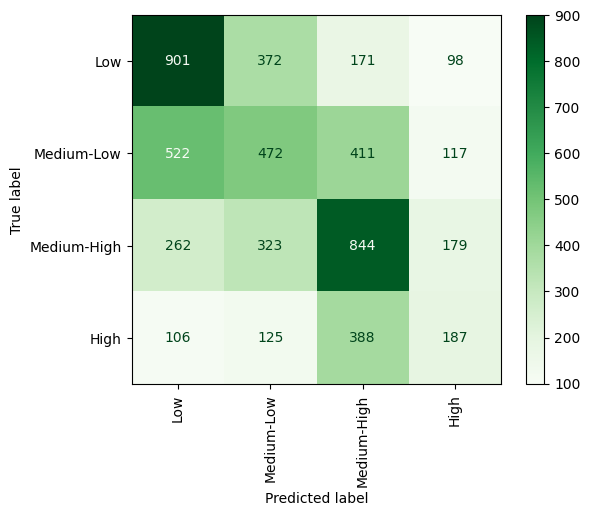

In [92]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_test_pred, y_true=y_test,
                                        xticks_rotation=90,
                                        cmap='Greens', display_labels= class_labels)
plt.show()

In this case, logRuntime is only at 5th place. The most important feature is tvEpisode: the first split can actually divide a decent amount of Low records (0 for 4213, 1 for 414 records) and Medium-Low.

After the fourth split we get a leaf, that is classified as Medium-High but is almost homogeneously divided amongst the first 3 classes - if other leaves are similar, we can understand the model's confusion, especially between neighboring classes.

At the fourth level we also find a discriminative split for movies that are not documentaries (mostly Low and Medium Low rating) from those which are: documentaries seem to be rated average to high, in fact they are the 4th most important feature. The second most important feature is StartYear, which manages to separate the small group of older movies (befor 1946), which are only around 500.

In [93]:
# Feature importance

zipped = zip(attributes, clf.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

tvEpisode 0.23962836139070082
startYear 0.13827485779386348
numVotes 0.1365270715915569
Documentary 0.07124812037721348
logRuntime 0.07025899077726942
movie 0.06854913058174016
numRegions 0.04301767004486405
awardsAndNominations 0.03033202436012324
totalCredits 0.028224093646236386
Horror 0.013530641853703214
criticReviewsRatio 0.012669503799965363
Animation 0.011353654154813044
Drama 0.011183261150023712
US 0.010708615067010575
IN 0.010550218321096714
canHaveEpisodes 0.010473727758980998
totalImages 0.009489616755751176
Music 0.008421854704185373
tvMovie 0.005694118234873419
numGenres 0.005639309151911122
Other 0.005404734124032898
News 0.005293173833898065
PH 0.005290531310517997
XWG 0.005190605964376297
TR 0.004127073973275669
Family 0.003819498994856851
Thriller 0.0037080147004597283
DE 0.003512421146293007
GB 0.003511563381075527
AU 0.0034033096327311867
Adventure 0.003096384833674009
Crime 0.002818448900160816
Short 0.0025675072293956593
videoGame 0.0023752844078035683
CA 0.00220

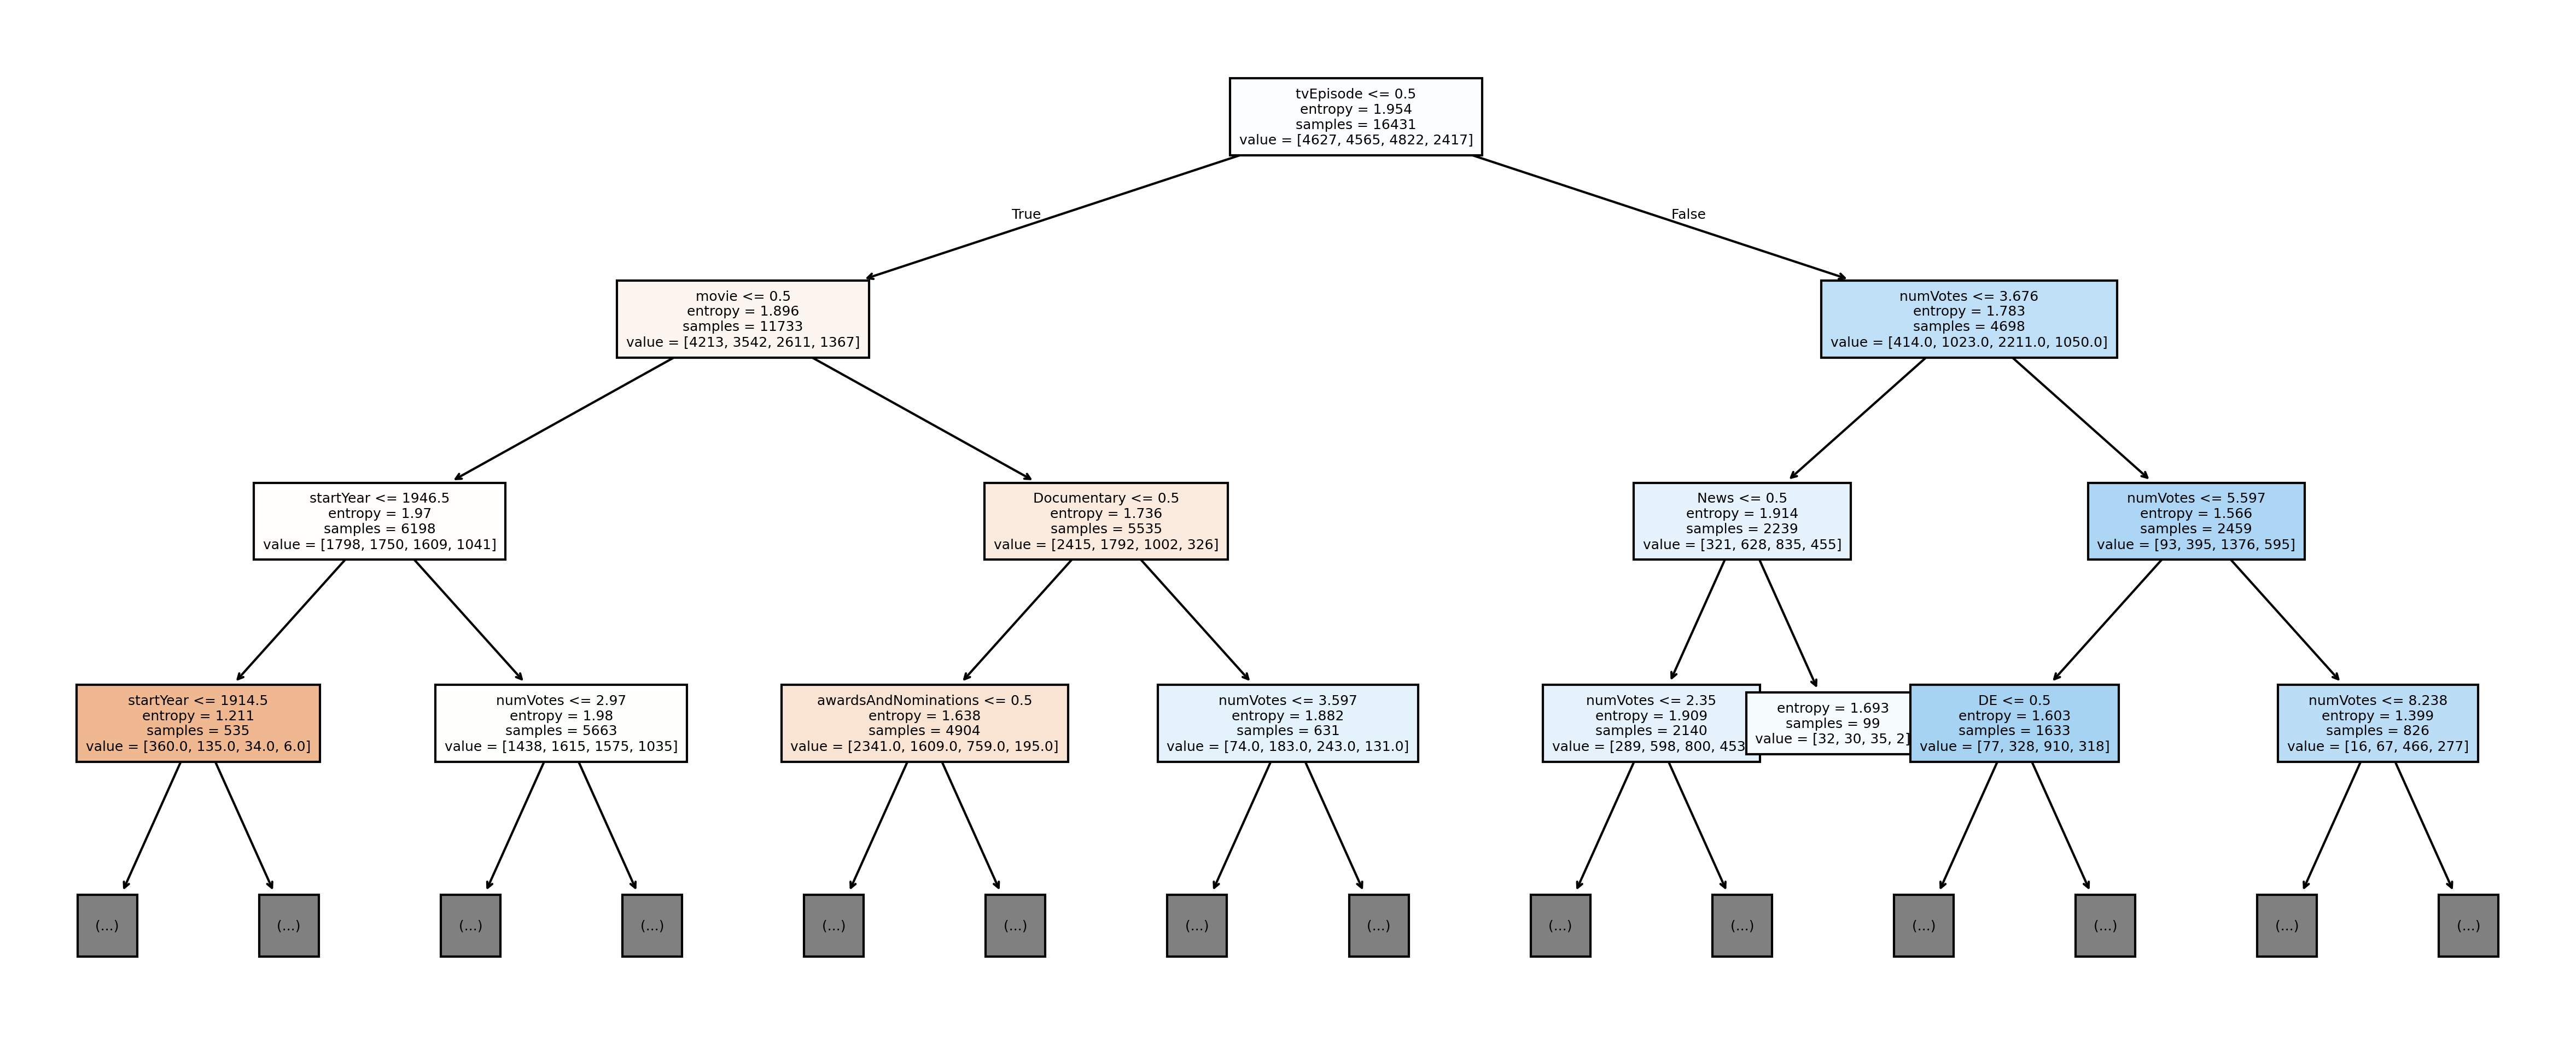

In [110]:
plt.figure(figsize=(20, 8), dpi=300)
plot_tree(clf, feature_names=attributes, filled=True, max_depth=3, fontsize=6)
plt.show()

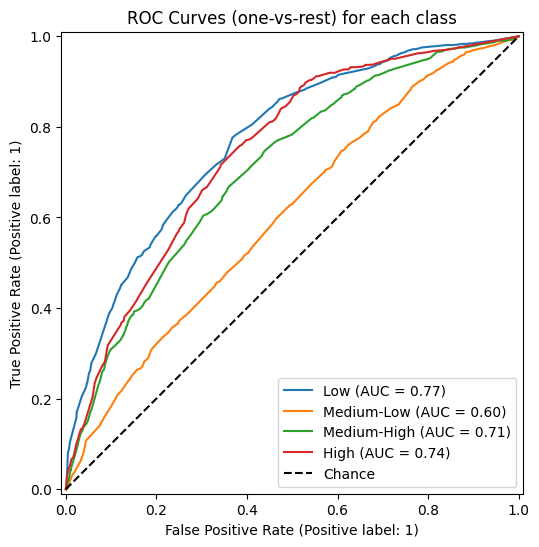

Macro-average ROC AUC: 0.706


In [97]:
#classes = np.unique(y_test)
#y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test) #predicted probabilities


plt.figure(figsize=(8, 6))
for i, class_label in zip(range(len(classes)), class_labels):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.legend()
plt.title("ROC Curves (one-vs-rest) for each class")
plt.show()

auc_score = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
print(f"Macro-average ROC AUC: {auc_score:.3f}")


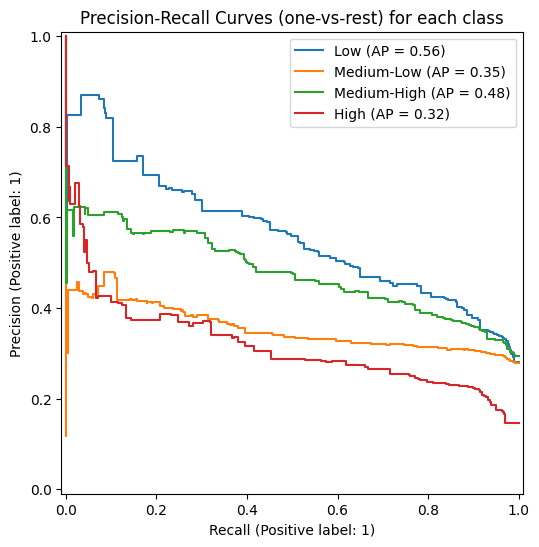

Macro average PR AUC: 0.427


In [96]:
plt.figure(figsize=(8, 6))
for i, class_label in zip(range(len(classes)), class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("Precision-Recall Curves (one-vs-rest) for each class")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")


All values have improved, more or less slightly (the most: High). The performances improve particularly for lower levels of recall.